# Metric Learning + OOD Detection

Обучаем CNN на 10 известных классах, берём embedding последнего скрытого слоя и определяем `-1` через расстояние до известных классов в embedding-space.

Технические функции и аугментации.

In [ ]:
from pathlib import Path
import random
import re

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [ ]:
TRAIN_DIR = Path('train_top10')
TEST_DIR = Path('test_filtered')
MODEL_PATH = Path('artifacts/metric_ood_model.pt')
EMB_PRED_PATH = Path('artifacts/metric_ood_predictions.csv')
SUB_PATH = Path('sample_submission_metric_ood.csv')

EPOCHS = 100
BATCH_SIZE = 32
TEST_BATCH_SIZE = 128
VAL_SIZE = 0.1
LR = 2e-4
EMBED_DIM = 64
TRIPLET_MARGIN = 0.3
SEED = 42

LABEL_RE = re.compile(r'label(-?\d+)')
IMAGE_ID_RE = re.compile(r'image(\d+)\.png$')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
print('cwd:', Path.cwd())
print('train exists:', TRAIN_DIR.exists())
print('test exists:', TEST_DIR.exists())
print('train files:', len(list(TRAIN_DIR.glob('*.png'))))
print('test files:', len(list(TEST_DIR.glob('*.png'))))

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def parse_label(path: Path) -> int:
    match = LABEL_RE.search(path.name)
    if match is None:
        raise ValueError(f'Bad filename: {path.name}')
    return int(match.group(1))


def parse_image_id(name: str) -> int:
    match = IMAGE_ID_RE.match(name)
    if match is None:
        raise ValueError(f'Bad image name: {name}')
    return int(match.group(1))


def load_image_tensor(path: Path, flip=False):
    with Image.open(path) as image:
        image = image.convert('L')
        if flip:
            image = ImageOps.mirror(image)
        arr = np.asarray(image, dtype=np.float32) / 255.0
        arr = (arr - 0.5) / 0.5
        return torch.tensor(arr[None, ...], dtype=torch.float32)


def augment_image_tensor(x: torch.Tensor) -> torch.Tensor:
    if random.random() < 0.5:
        x = torch.flip(x, dims=[2])

    if random.random() < 0.5:
        x = x + 0.05 * torch.randn_like(x)

    if random.random() < 0.3:
        shift_x = random.randint(-3, 3)
        shift_y = random.randint(-3, 3)
        x = torch.roll(x, shifts=(shift_y, shift_x), dims=(1, 2))

    if random.random() < 0.3:
        scale = random.uniform(0.85, 1.15)
        x = x * scale

    return x.clamp(-1.0, 1.0)


def load_train_samples(data_dir: Path):
    paths = sorted(data_dir.glob('*.png'))
    return [(path, parse_label(path)) for path in paths]


### MetricTrainDataset

Датасет для обучения модели.  
Загружает изображения и соответствующие метки классов.  
При включённой аугментации применяет случайные преобразования к изображениям.  
Метки классов преобразуются в индексы от `0` до `N-1`.



### TestDataset

Датасет для тестирования.  
Загружает изображения без меток.  
Возвращает тензор изображения и имя файла, которое используется для формирования submission.



### EmbeddingCNN

Сверточная нейросеть, которая:
- извлекает признаки изображения (CNN feature extractor),
- преобразует их в embedding фиксированной размерности,
- нормализует embedding (для сравнения по расстоянию),
- выполняет классификацию по embedding.

На выходе возвращает:
- `logits` — для задачи классификации,
- `embedding` — для metric learning и определения неизвестных классов (`-1`).

In [ ]:
class MetricTrainDataset(Dataset):
    def __init__(self, samples, class_to_idx, augment=True):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x = load_image_tensor(path)
        if self.augment:
            x = augment_image_tensor(x)
        y = self.class_to_idx[label]
        return x, y


class TestDataset(Dataset):
    def __init__(self, data_dir: Path):
        self.paths = [path for path in data_dir.iterdir() if path.suffix == '.png']

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        return load_image_tensor(path), path.name


class EmbeddingCNN(nn.Module):
    def __init__(self, num_classes, embed_dim=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.backbone = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        emb = self.backbone(x)
        emb = F.normalize(emb, dim=1)
        logits = self.classifier(emb)
        return logits, emb


### Batch Hard Triplet Loss

Функция `batch_hard_triplet_loss` реализует подход metric learning, который учит модель формировать пространство признаков (embeddings), где:

- объекты одного класса находятся близко друг к другу,
- объекты разных классов — далеко друг от друга.


#### Основная идея

Для каждого изображения (anchor) выбираются:
- positive — пример того же класса,
- negative — пример другого класса.

Цель обучения:

**distance(anchor, positive) < distance(anchor, negative)**

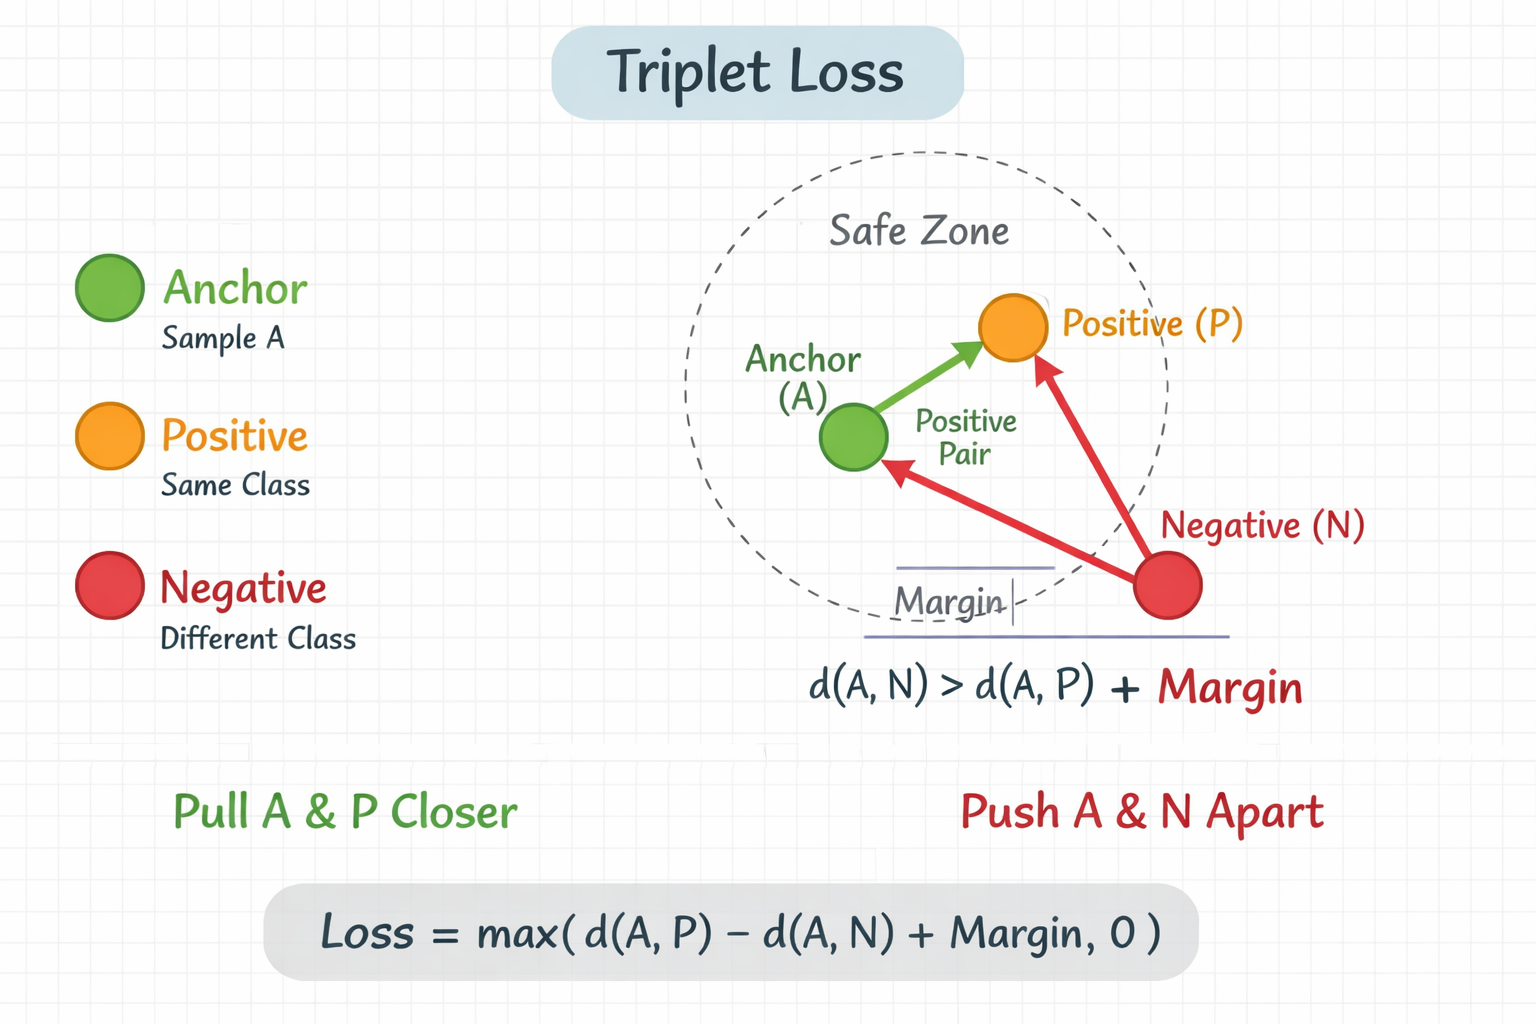

Triplet loss обучает модель формировать пространство признаков (embeddings), в котором объекты одного класса находятся ближе друг к другу, а объекты разных классов — дальше.

- Для каждой картинки (anchor) внутри батча выбирается самый “сложный” положительный пример (hardest positive — самый дальний объект того же класса) и самый “опасный” отрицательный пример (hardest negative — самый близкий объект другого класса).
- Затем считается расстояние до них: d_pos и d_neg, и применяется функция потерь:
$$loss = max(0, Hpos - Hneg + margin).$$
- Если объект своего класса уже ближе, чем чужого (с учётом зазора margin), ошибка равна нулю; иначе модель получает штраф и учится сближать свои классы и раздвигать разные.

В результате формируется пространство, где каждый класс образует компактный кластер, что позволяет не только классифицировать известные классы, но и находить новые (например, класс -1) по большому расстоянию до всех кластеров.

In [ ]:
def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    distances = torch.cdist(embeddings, embeddings, p=2) # Матрица расстояний между эмбеддингами объектов
    labels = labels.unsqueeze(1)
    same = labels.eq(labels.T) # маска одинаковых классов
    diff = ~same # маска различных классов

    # пример:
    # labels = [0, 0, 1]

    # same =
    # [[True,  True,  False],
    # [True,  True,  False],
    # [False, False, True ]]

    same.fill_diagonal_(False) # убираем учет самой картинки из маски

    positive_dist = distances.masked_fill(~same, -1e9) # считаем расстояния до объектов своего класса (для других ставим -1e9)
    negative_dist = distances.masked_fill(~diff, 1e9) # считаем расстояния до объектов чужого класса (для других ставим 1e9)

    hardest_positive = positive_dist.max(dim=1).values
    hardest_negative = negative_dist.min(dim=1).values

    valid = (hardest_positive > -1e8) & (hardest_negative < 1e8) # защита от пустых батчей
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device)

    loss = F.relu(hardest_positive[valid] - hardest_negative[valid] + margin)
    return loss.mean()

Далее - функция для оценки accuracy модели.

In [ ]:
def evaluate_cls(model, loader, device):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits, _ = model(x)
            pred = logits.argmax(dim=1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return correct / max(total, 1)

Функция для сбора эмбеддингов

In [ ]:
def collect_embeddings(model, loader, device):
    model.eval()
    all_embeddings = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, emb = model(x)
            all_embeddings.append(emb.cpu())
            all_labels.append(y.cpu())
    return torch.cat(all_embeddings), torch.cat(all_labels)

Ниже - функция для вычисления прототипов классов (centroids) в embedding-пространстве.

Мы хотим для каждого класса иметь одну “центральную точку” (prototype) в пространстве признаков, чтобы потом можно было сравнивать новые изображения с этими центрами.

In [ ]:
def compute_class_prototypes(embeddings, labels, num_classes):
    prototypes = []
    for class_idx in range(num_classes):
        class_emb = embeddings[labels == class_idx]
        proto = class_emb.mean(dim=0)
        proto = F.normalize(proto.unsqueeze(0), dim=1).squeeze(0)
        prototypes.append(proto)
    return torch.stack(prototypes)

Следующая функция собирает расстояния от эмбеддингов правильно классифицированных изображений до центров классов (prototypes), чтобы понять, насколько изображения “типичные” для своих классов. Она используется для выбора порога, после которого объекты можно относить к неизвестному классу (-1).

In [ ]:
def collect_val_distances(model, loader, prototypes, device):
    model.eval()
    all_distances = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, emb = model(x)
            pred = logits.argmax(dim=1).cpu()
            emb = emb.cpu()
            correct_mask = pred.eq(y)
            if correct_mask.sum() == 0:
                continue
            good_emb = emb[correct_mask]
            dists = torch.cdist(good_emb, prototypes.cpu()).min(dim=1).values
            all_distances.append(dists)
    if not all_distances:
        return torch.tensor([1.0])
    return torch.cat(all_distances)

## Обучение

- Сначала модель обучается на train_loader (с классификацией + triplet loss).

- После окончания обучения (и выбора лучшей модели по val_acc) мы один раз прогоняем все тренировочные изображения через модель без аугментации (train_eval_loader) и строим прототипы классов.

- Эти прототипы потом уже не меняются и используются для сравнения новых изображений с известными классами, а также для определения, что изображение слишком далеко от всех центров - класс -1.

In [ ]:
seed_everything(SEED)

samples = load_train_samples(TRAIN_DIR)
labels = sorted({label for _, label in samples})
class_to_idx = {label: i for i, label in enumerate(labels)}
idx_to_class = {i: label for label, i in class_to_idx.items()}

train_samples, val_samples = train_test_split(
    samples,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=[label for _, label in samples],
)

print('train size:', len(train_samples))
print('val size:', len(val_samples))

train_ds = MetricTrainDataset(train_samples, class_to_idx, augment=True)
val_ds = MetricTrainDataset(val_samples, class_to_idx, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

train_eval_loader = DataLoader(MetricTrainDataset(train_samples, class_to_idx, augment=False), batch_size=BATCH_SIZE, shuffle=False)
# для сбора embedding всех тренировочных изображений без аугментации, нужен для построения прототипов классов.

model = EmbeddingCNN(num_classes=len(labels), embed_dim=EMBED_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
ce_loss = nn.CrossEntropyLoss()

best_acc = -1.0
best_state = None

for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits, emb = model(x)
        loss_cls = ce_loss(logits, y)
        loss_metric = batch_hard_triplet_loss(emb, y, margin=TRIPLET_MARGIN)
        loss = loss_cls + 0.5 * loss_metric

        # loss_cls (CrossEntropyLoss) - классическая классификация 10 известных классов
        # loss_metric (batch_hard_triplet_loss) - metric learning, учит embeddings быть компактными для своих классов и раздвигать чужие

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_acc = evaluate_cls(model, val_loader, device)
    print(f'epoch={epoch + 1} val_acc={val_acc:.4f}')

    if val_acc > best_acc:
        best_acc = val_acc
        best_state = model.state_dict()

model.load_state_dict(best_state)

train_embeddings, train_targets = collect_embeddings(model, train_eval_loader, device)
# Прогоняем весь train_eval_loader (без аугментации) через модель
# Получаем:
# train_embeddings — векторы признаков всех тренировочных картинок
# train_targets — их настоящие классы

prototypes = compute_class_prototypes(train_embeddings, train_targets, num_classes=len(labels))
# Для каждого класса считаем средний embedding - центр кластера (прототип)

val_distances = collect_val_distances(model, val_loader, prototypes, device)
# Берём все правильные предсказания на валидации
# Для каждого embedding вычисляем расстояние до ближайшего прототипа
# Получаем распределение нормальных расстояний для известных классов

distance_threshold = torch.quantile(val_distances, 0.95).item()
# все что дальше 95%-й квантили - неизвестный класс

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        'model_state': model.state_dict(),
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'prototypes': prototypes,
        'distance_threshold': distance_threshold,
    },
    MODEL_PATH,
)

print('saved model to', MODEL_PATH)
print('best val_acc =', best_acc)
print('distance_threshold =', distance_threshold)


train size: 421
val size: 106
epoch=1 val_acc=0.1792
epoch=2 val_acc=0.1792
epoch=3 val_acc=0.1792
epoch=4 val_acc=0.1792
epoch=5 val_acc=0.1792
epoch=6 val_acc=0.1792
epoch=7 val_acc=0.1792
epoch=8 val_acc=0.1792
epoch=9 val_acc=0.1792
epoch=10 val_acc=0.1792
epoch=11 val_acc=0.2358
epoch=12 val_acc=0.4434
epoch=13 val_acc=0.5094
epoch=14 val_acc=0.5283
epoch=15 val_acc=0.5943
epoch=16 val_acc=0.6415
epoch=17 val_acc=0.7170
epoch=18 val_acc=0.8208
epoch=19 val_acc=0.7358
epoch=20 val_acc=0.8396
epoch=21 val_acc=0.8019
epoch=22 val_acc=0.7736
epoch=23 val_acc=0.8208
epoch=24 val_acc=0.7925
epoch=25 val_acc=0.8396
epoch=26 val_acc=0.8302
epoch=27 val_acc=0.8019
epoch=28 val_acc=0.7358
epoch=29 val_acc=0.7925
epoch=30 val_acc=0.8113
epoch=31 val_acc=0.8113
epoch=32 val_acc=0.8113
epoch=33 val_acc=0.8585
epoch=34 val_acc=0.8491
epoch=35 val_acc=0.8208
epoch=36 val_acc=0.8208
epoch=37 val_acc=0.8208
epoch=38 val_acc=0.8113
epoch=39 val_acc=0.8019
epoch=40 val_acc=0.8396
epoch=41 val_acc=0.

## Делаем прогноз

In [ ]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
idx_to_class = {int(k): int(v) for k, v in checkpoint['idx_to_class'].items()}
prototypes = checkpoint['prototypes'].to(device)
distance_threshold = float(checkpoint['distance_threshold'])

model = EmbeddingCNN(num_classes=len(idx_to_class), embed_dim=EMBED_DIM).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

test_ds = TestDataset(TEST_DIR)
test_loader = DataLoader(test_ds, batch_size=TEST_BATCH_SIZE, shuffle=False)

rows = []
with torch.no_grad():
    for x, names in test_loader:
        x = x.to(device)
        logits, emb = model(x)
        pred = logits.argmax(dim=1)
        dists = torch.cdist(emb, prototypes).min(dim=1).values

        for name, pred_idx, dist in zip(names, pred.cpu().tolist(), dists.cpu().tolist()):
            pred_label = -1 if dist > distance_threshold else idx_to_class[pred_idx]
            rows.append((name, pred_label, dist))

rows.sort(key=lambda row: parse_image_id(row[0]))

pred_df = pd.DataFrame(rows, columns=['filename', 'pred_label', 'distance'])
EMB_PRED_PATH.parent.mkdir(parents=True, exist_ok=True)
pred_df.to_csv(EMB_PRED_PATH, index=False)
pred_df.head()


,filename,pred_label,distance
0,image1.png,1,0.169286
1,image2.png,28,0.367384
2,image3.png,28,0.094933
3,image6.png,16,0.253661
4,image9.png,16,0.408016


In [ ]:
submission_df = pred_df[['filename', 'pred_label']].rename(columns={'filename': 'img_name', 'pred_label': 'pred_class'})
submission_df.to_csv(SUB_PATH, index=False)
print('saved submission to', SUB_PATH)
submission_df.head()

saved submission to sample_submission_metric_ood.csv


,img_name,pred_class
0,image1.png,1
1,image2.png,28
2,image3.png,28
3,image6.png,16
4,image9.png,16
